In [ ]:
!nvidia-smi

In [1]:
import os

# Make only GPU 7 visible to TensorFlow
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import tensorflow as tf

# List the visible GPUs (GPU 7 will appear as GPU 0 to TensorFlow)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Allow memory growth instead of setting a fixed limit
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"Using GPU 3 (seen as GPU 0 by TF): {len(gpus)} physical, {len(logical_gpus)} logical GPUs")
    except RuntimeError as e:
        print("TF GPU setup error:", e)
else:
    print("No GPU available. Running on CPU.")

2025-12-09 09:07:57.567848: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-09 09:07:58.285260: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Using GPU 3 (seen as GPU 0 by TF): 1 physical, 1 logical GPUs


2025-12-09 09:07:59.372956: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20574 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:35:00.0, compute capability: 8.9


In [2]:
import os
import cv2
import numpy as np
import pywt
import scipy.stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from skimage.feature import graycomatrix, graycoprops
from tensorflow.keras.utils import to_categorical
import umap
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Concatenate, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.tree import DecisionTreeClassifier, _tree, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import itertools
import tqdm
from transformers import TFViTModel, ViTFeatureExtractor
import gc



In [3]:

# --- CONFIGURATION ---

IMG_SIZE = (224, 224)
WAVELET = 'db1'
RESULT_PATH = './CC-D3r6-Latest'

def parse_respath(*pathfrag):
    path = os.path.join(RESULT_PATH, *pathfrag)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    return path

In [4]:
# BC prefix => borrowed code

class BC_FeatureExtractor:

    @staticmethod
    def _wavelet_stats(subband):
        return [
            np.mean(subband),
            np.std(subband),
            np.var(subband),
            scipy.stats.entropy(np.abs(subband.flatten()) + 1e-6)
        ]

    @classmethod
    def extract_wavelet_stats(cls, image, wavelet='db1'):
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        coeffs2 = pywt.dwt2(gray, wavelet)
        LL, (LH, HL, HH) = coeffs2
        features = list()
        for band in [LL, LH, HL, HH]:
            features.extend(cls._wavelet_stats(band))
        hh_energy = np.sum(np.square(HH))
        features.append(hh_energy)
        return features

    @staticmethod
    def extract_glcm_features_extended(image):
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        angles = [0, np.pi/4, np.pi/2]
        glcm = graycomatrix(gray, distances=[5], angles=angles, levels=256, symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast').mean()
        dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
        homogeneity = graycoprops(glcm, 'homogeneity').mean()
        return [contrast, dissimilarity, homogeneity]


In [5]:
import csv, os
from collections import namedtuple

class BaseDataDir:
        
    def _assert_files(self):
        discard = list()
        for i, f in enumerate(self.files):
            if not os.path.exists(f):
                print(f'warning: cannot resolve file {f}')
                discard.append(i)
        for i in reversed(discard):
            self.files.pop(i)

    def get_label(self, i):
        path = self.files[i]
        return self.get_label_from_path(path)
    
    def load(self, i):
        path = self.files[i]
        label = self.get_label_from_path(path)
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # img = img[30:430, 200:550]
        img = cv2.resize(img, IMG_SIZE)
        features = list()
        features.extend(BC_FeatureExtractor.extract_wavelet_stats(img, wavelet=WAVELET))
        features.extend(BC_FeatureExtractor.extract_glcm_features_extended(img))
        return img, features, label

    def imshows4(self, indices):
        fig, axs = plt.subplots(2, 2, figsize=(8, 4*2))
        for n, i in enumerate(indices):
            img, _, _ = self.load(i)
            axs[n//2, n%2].imshow(img)
            # axs[n//2, n%2].set_title(self.files[i])
        return fig

In [6]:
class DataDirHyperKvasir(BaseDataDir):
    nt_labels = namedtuple('Label', ['organ','finding','classification','train_test'])

    def __init__(self, path):
        self.path = path
        self.labels = dict()
        self.files = list()
        self.nfiles = 0
        self._labels_csv_path = f'{path}/labeled-images/image-labels.csv'
        if not os.path.exists(self._labels_csv_path):
            raise FileNotFoundError('cant resolve labels csv file')
        with open(self._labels_csv_path) as fp:
            reader = csv.reader(fp)
            _ = next(reader) # ignore column header
            for filename, *row in reader:
                self.labels[filename] = self.nt_labels(*row, -1)
        self._images_path = f'{path}/labeled-images'
        for root, dirs, files in os.walk(self._images_path):
            if '.ipynb_checkpoints' in root: continue
            for f in files:
                if not f.endswith(('bmp', 'jpg', 'png', 'jpeg', 'jfif', 'webp')): continue
                if not f.rpartition('.')[0] in self.labels: continue
                self.files.append(os.path.join(root, f))
        self._assert_files()
        self.nfiles = len(self.files)
        print(f'found {self.nfiles} files')
        self.train_indices = np.array(range(self.nfiles))
        self.test_indices = None

    def get_label_from_path(self, path):
        filename = path.rpartition(os.path.sep)[-1].rpartition('.')[0]
        return self.labels[filename]

datadir_hyper = DataDirHyperKvasir('./Dataset/HyperKvasir')
# _ = datadir_hyper.imshows4(np.random.randint(0, datadir_hyper.nfiles, size=4))

found 10662 files


In [7]:
class DataDirTMCUCM(BaseDataDir):
    nt_labels = namedtuple('Label', ['MES','train_test'])

    def __init__(self, path, ignore_augment=True):
        self.path = path
        self.labels = dict()
        self.files = list()
        self.nfiles = 0
        self.train_indices = list()
        self.test_indices = list()

        self._labels_train_csv_path = f'{path}/train.txt'
        if not os.path.exists(self._labels_train_csv_path):
            raise FileNotFoundError('cant resolve labels csv file')
        with open(self._labels_train_csv_path) as fp:
            reader = csv.reader(fp, delimiter=' ')
            for filepath, mes in reader:
                if ignore_augment and 'augment' in filepath: continue
                filename = '/'.join(filepath.split('/')[-2:])
                self.labels[filename] = self.nt_labels(f'MES{int(mes)}', 0)
                self.files.append(f'{self.path}/{filename}')
                self.train_indices.append(len(self.files)-1)

        self._labels_test_csv_path = f'{path}/test.txt'
        if not os.path.exists(self._labels_test_csv_path):
            raise FileNotFoundError('cant resolve labels csv file')
        with open(self._labels_test_csv_path) as fp:
            reader = csv.reader(fp, delimiter=' ')
            for filepath, mes in reader:
                if ignore_augment and 'augment' in filepath: continue
                filename = '/'.join(filepath.split('/')[-2:])
                self.labels[filename] = self.nt_labels(f'MES{int(mes)}', 1)
                self.files.append(f'{self.path}/{filename}')
                self.test_indices.append(len(self.files)-1)
        self._assert_files()
        self.nfiles = len(self.files)
        print(f'found {self.nfiles} files')
        self.train_indices = np.array(self.train_indices)
        self.test_indices = np.array(self.test_indices)

    def get_label_from_path(self, path):
        filename = '/'.join(path.split('/')[-2:])
        return self.labels[filename]

    def load_indices(self, indices):
        imgs = list()
        features = list()
        labels = list()
        for i in tqdm.auto.tqdm(indices):
            img, feature, label = self.load(i)
            imgs.append(img)
            features.append(feature)
            labels.append(label[0])
        return np.array(imgs), np.array(features), np.array(labels)

datadir_tmcucm = DataDirTMCUCM('./Dataset/TMC-UCM')
# _ = datadir_tmcucm.imshows4(np.random.randint(0, datadir_tmcucm.nfiles, size=4))

found 7978 files


In [8]:
class DataDirLIMUC(BaseDataDir):
    nt_labels = namedtuple('Label', ['MES','train_test'])

    def __init__(self, path):
        self.path = path
        self.labels = dict()
        self.files = list()
        self.nfiles = 0
        self.train_indices = list()
        self.test_indices = list()
        self._dir_train = f'{path}/train_and_validation_sets'
        self._dir_test = f'{path}/test_set'

        for label in os.listdir(self._dir_train):
            subpath = os.path.join(self._dir_train, label)
            if not os.path.isdir(subpath): continue
            for f in os.listdir(subpath):
                if not f.endswith(('bmp', 'jpg', 'jpeg', 'png', 'jfif', 'webp')): continue
                filepath = os.path.join(subpath, f)
                self.files.append(filepath)
                key = '/'.join(filepath.split('/')[-2:])
                self.labels[key] = self.nt_labels('MES'+label[-1], -1)
        self.train_indices = range(len(self.files))

        for label in os.listdir(self._dir_test):
            subpath = os.path.join(self._dir_test, label)
            if not os.path.isdir(subpath): continue
            for f in os.listdir(subpath):
                if not f.endswith(('bmp', 'jpg', 'jpeg', 'png', 'jfif', 'webp')): continue
                filepath = os.path.join(subpath, f)
                self.files.append(filepath)
                key = '/'.join(filepath.split('/')[-2:])
                self.labels[key] = self.nt_labels('MES'+label[-1], -1)
        self.test_indices = range(len(self.train_indices), len(self.files))
        self._assert_files()
        self.nfiles = len(self.files)
        print(f'found {self.nfiles} files')
        self.train_indices = np.array(self.train_indices)
        self.test_indices = np.array(self.test_indices)


    def load(self, i):
        path = self.files[i]
        label = self.get_label_from_path(path)
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # print(img.shape)
        img = img[36+20:288-14-20, 22:352-16]
        img = cv2.resize(img, IMG_SIZE)
        features = list()
        features.extend(BC_FeatureExtractor.extract_wavelet_stats(img, wavelet=WAVELET))
        features.extend(BC_FeatureExtractor.extract_glcm_features_extended(img))
        return img, features, label

    def get_label_from_path(self, path):
        filename = '/'.join(path.split('/')[-2:])
        return self.labels[filename]

    def load_indices(self, indices):
        imgs = list()
        features = list()
        labels = list()
        for i in tqdm.auto.tqdm(indices):
            img, feature, label = self.load(i)
            imgs.append(img)
            features.append(feature)
            labels.append(label[0])
        return np.array(imgs), np.array(features), np.array(labels)

datadir_limuc = DataDirLIMUC('./Dataset/LIMUC')
# _ = datadir_limuc.imshows4(np.random.randint(0, datadir_limuc.nfiles, size=4))

datadir_limuc.train_indices.shape, datadir_limuc.test_indices.shape

found 11276 files


((9590,), (1686,))

In [9]:
class DataDirDefault(BaseDataDir):
    nt_labels = namedtuple('Label', ['MES','train_test'])

    def __init__(self, path):
        self.path = path
        self.labels = dict()
        self.files = list()
        self.nfiles = 0
        self.train_indices = list()
        self.test_indices = list()
        for label in os.listdir(self.path):
            subpath = os.path.join(self.path, label)
            if not os.path.isdir(subpath): continue
            for f in os.listdir(subpath):
                if not f.endswith(('bmp', 'jpg', 'jpeg', 'png', 'jfif', 'webp')): continue
                filepath = os.path.join(subpath, f)
                self.files.append(filepath)
                key = '/'.join(filepath.split('/')[-2:])
                self.labels[key] = self.nt_labels(label, -1)
        self._assert_files()
        self.nfiles = len(self.files)
        print(f'found {self.nfiles} files')
        self.train_indices = np.array(self.train_indices)
        self.test_indices = np.array(self.test_indices)

    def load(self, i):
        path = self.files[i]
        label = self.get_label_from_path(path)
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img[30:430, 200:550]
        img = cv2.resize(img, IMG_SIZE)
        features = list()
        features.extend(BC_FeatureExtractor.extract_wavelet_stats(img, wavelet=WAVELET))
        features.extend(BC_FeatureExtractor.extract_glcm_features_extended(img))
        return img, features, label

    def get_label_from_path(self, path):
        filename = '/'.join(path.split('/')[-2:])
        return self.labels[filename]

    def load_indices(self, indices):
        imgs = list()
        features = list()
        labels = list()
        for i in tqdm.auto.tqdm(indices):
            img, feature, label = self.load(i)
            imgs.append(img)
            features.append(feature)
            labels.append(label[0])
        return np.array(imgs), np.array(features), np.array(labels)

datadir_mixed = DataDirDefault('./Dataset+Code/MES Mixed Data')

ls1 = set(os.listdir('./Dataset+Code/MES Mixed Data/MES1'))
ls2 = set(os.listdir('./Dataset+Code/MES Mixed Data/MES2'))
ls1.intersection(ls2)


found 997 files


{'.DS_Store',
 '6316984_20240927_ES_1_13_13.jpg',
 '6316984_20240927_ES_1_14_14.jpg'}

In [10]:
# plt.imshow(datadir_mixed.load(1)[0])

found 11276 files


  0%|          | 0/3 [00:00<?, ?it/s]

train: 8000
test:  1000


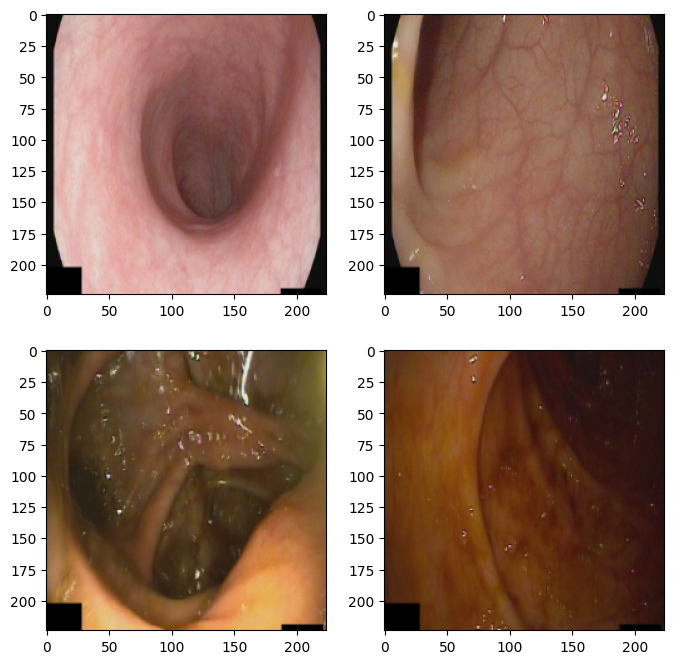

In [11]:
# here onwards is used for training
# here onwards is used for training

np.random.seed(42)

# datadir = DataDirTMCUCM('./Dataset/TMC-UCM')
datadir = DataDirLIMUC('./Dataset/LIMUC')

# truncate
np.random.shuffle(datadir.train_indices)
np.random.shuffle(datadir.test_indices)
datadir.train_indices = datadir.train_indices[:8000]
datadir.test_indices = datadir.test_indices[:1000]

_, _, labels = datadir.load_indices([1,2,3])
print('train:', datadir.train_indices.shape[0])
print('test: ', datadir.test_indices.shape[0])
labels

fig = datadir.imshows4(np.random.randint(0, datadir.nfiles, size=4))
fig.savefig(parse_respath('dataset-examples.png'))

In [ ]:
# --- LOAD TRAINING + TEST SET ---
X_img_train_raw, X_feat_train_raw, y_train_label = datadir.load_indices(datadir.train_indices[:])
X_img_test_raw,  X_feat_test_raw,  y_test_label  = datadir.load_indices(datadir.test_indices[:])
img_paths = np.array(datadir.files)
img_paths_train = img_paths[datadir.train_indices[:]]
img_paths_test = img_paths[datadir.test_indices[:]]


# --- NORMALIZE IMAGES ---
X_img_train = X_img_train_raw.astype(np.float32) / 255.0
X_img_test  = X_img_test_raw.astype(np.float32) / 255.0

# --- LABEL ENCODING ---
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_label)
y_test_encoded  = le.transform(y_test_label)
y_train_cat = to_categorical(y_train_encoded, num_classes=len(le.classes_))
y_test_cat  = to_categorical(y_test_encoded,  num_classes=len(le.classes_))

# --- FEATURE SCALING ---
scaler = StandardScaler()
X_feat_train_scaled = scaler.fit_transform(X_feat_train_raw)
X_feat_test_scaled  = scaler.transform(X_feat_test_raw)

# --- APPLY SMOTE TO TRAINING SET ---
smote = SMOTE(random_state=42)
X_feat_train_bal, y_train_bal = smote.fit_resample(X_feat_train_scaled, y_train_encoded)


# --- MAP BALANCED FEATURES TO REAL IMAGES ---
X_img_train_bal, img_paths_train_bal = [], []
for feat, label in zip(X_feat_train_bal, y_train_bal):
    dists = np.linalg.norm(X_feat_train_scaled[y_train_encoded == label] - feat, axis=1)
    idx = np.where(y_train_encoded == label)[0][np.argmin(dists)]
    X_img_train_bal.append(X_img_train[idx])
    img_paths_train_bal.append(img_paths_train[idx])
X_img_train_bal = np.array(X_img_train_bal, dtype=np.float32)
y_train_cat_bal = to_categorical(y_train_bal, num_classes=len(le.classes_))

# --- UMAP PROJECTION (fit on training, apply to test) ---
umap_reducer = umap.UMAP(n_neighbors=10, min_dist=0.05, n_components=2, metric='euclidean', random_state=42)
X_train_umap = umap_reducer.fit_transform(X_feat_train_bal)
X_test_umap  = umap_reducer.transform(X_feat_test_scaled)

# --- SHAPE SUMMARY ---
print(f"X_img_train_bal: {X_img_train_bal.shape}, X_img_test: {X_img_test.shape}")
print(f"X_feat_train_bal: {X_feat_train_bal.shape}, X_feat_test_scaled: {X_feat_test_scaled.shape}")
print(f"X_train_umap: {X_train_umap.shape}, X_test_umap: {X_test_umap.shape}")
print(f"y_train_cat_bal: {y_train_cat_bal.shape}, y_test_cat: {y_test_cat.shape}")


  0%|          | 0/8000 [00:00<?, ?it/s]

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(8, 4*3))

# --- PLOT TRAIN CLASS DISTRIBUTION (Before SMOTE) ---
axs[0].set_title("Training Set Class Distribution (Before SMOTE)")
axs[0].set_xlabel("Class")
axs[0].set_ylabel("Count")
axs[0].bar(*np.unique(y_train_encoded, return_counts=True), tick_label=le.classes_)
axs[0].grid(True)

# --- PLOT TEST CLASS DISTRIBUTION ---
axs[1].set_title("Testing Set Class Distribution")
axs[1].set_xlabel("Class")
axs[1].set_ylabel("Count")
axs[1].bar(*np.unique(y_test_encoded, return_counts=True), tick_label=le.classes_, color='orange')
axs[1].grid(True)

# --- PLOT TRAIN CLASS DISTRIBUTION ---
axs[2].set_title("Training Set Class Distribution (After SMOTE)")
axs[2].set_xlabel("Class")
axs[2].set_ylabel("Count")
axs[2].bar(*np.unique(y_train_bal, return_counts=True), tick_label=le.classes_, color='green')
axs[2].grid(True)

fig.savefig(parse_respath('class-distribution.png'))
fig.tight_layout()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Rescale to 0–255 for visualization purposes ---
train_original = X_img_train * 255.0
test_original  = X_img_test * 255.0

# --- Flatten pixel values across all channels and images ---
train_pixels_orig = train_original.flatten()
test_pixels_orig  = test_original.flatten()

train_pixels_norm = X_img_train.flatten()
test_pixels_norm  = X_img_test.flatten()


In [ ]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Use handcrafted feature names
feature_names = [
    'LL_mean', 'LL_std', 'LL_var', 'LL_entropy',
    'LH_mean', 'LH_std', 'LH_var', 'LH_entropy',
    'HL_mean', 'HL_std', 'HL_var', 'HL_entropy',
    'HH_mean', 'HH_std', 'HH_var', 'HH_entropy',
    'GLCM_contrast', 'GLCM_dissimilarity', 'GLCM_homogeneity',
    'HH_energy'
]

# Create raw DataFrames
df_train_raw = pd.DataFrame(X_feat_train_raw[:, :20], columns=feature_names)
df_test_raw  = pd.DataFrame(X_feat_test_raw[:, :20],  columns=feature_names)

# Standardize using same scaler
scaler = StandardScaler()
df_train_scaled = pd.DataFrame(scaler.fit_transform(df_train_raw), columns=feature_names)
df_test_scaled  = pd.DataFrame(scaler.transform(df_test_raw),  columns=feature_names)

fig, axs = plt.subplots(4, 1, figsize=(12, 5*4))

# Plot 1: Train - Before Scaling
sns.boxplot(data=df_train_raw, ax=axs[0])
axs[0].set_title("Train Set - Handcrafted Features (Before Standardization)")
axs[0].tick_params(axis='x', labelrotation=45) # ha='right'
axs[0].grid(True)

# Plot 2: Train - After Scaling
sns.boxplot(data=df_train_scaled, ax=axs[1])
axs[1].set_title("Train Set - Handcrafted Features (After Standardization)")
axs[1].tick_params(axis='x', labelrotation=45) # ha='right'
axs[1].grid(True)

# Plot 3: Test - Before Scaling
sns.boxplot(data=df_test_raw, ax=axs[2])
axs[2].set_title("Test Set - Handcrafted Features (Before Standardization)")
axs[2].tick_params(axis='x', labelrotation=45) # ha='right'
axs[2].grid(True)

# Plot 4: Test - After Scaling
sns.boxplot(data=df_test_scaled, ax=axs[3])
axs[3].set_title("Test Set - Handcrafted Features (After Standardization)")
axs[3].tick_params(axis='x', labelrotation=45) # ha='right'
axs[3].grid(True)

fig.savefig(parse_respath('scaled-features0.png'))
fig.tight_layout()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Handcrafted feature names
feature_names = [
    'LL_mean', 'LL_std', 'LL_var', 'LL_entropy',
    'LH_mean', 'LH_std', 'LH_var', 'LH_entropy',
    'HL_mean', 'HL_std', 'HL_var', 'HL_entropy',
    'HH_mean', 'HH_std', 'HH_var', 'HH_entropy',
    'HH_energy', 'GLCM_contrast', 'GLCM_dissimilarity', 'GLCM_homogeneity'
]

# Prepare raw DataFrames
X_feats_train = np.array(X_feat_train_raw, dtype=np.float32)
X_feats_test  = np.array(X_feat_test_raw, dtype=np.float32)
df_train_raw = pd.DataFrame(X_feats_train, columns=feature_names)
df_test_raw  = pd.DataFrame(X_feats_test,  columns=feature_names)

# Standardize using same scaler (like in real pipeline)
scaler = StandardScaler()
X_feats_train_scaled = scaler.fit_transform(X_feats_train)
X_feats_test_scaled  = scaler.transform(X_feats_test)
df_train_scaled = pd.DataFrame(X_feats_train_scaled, columns=feature_names)
df_test_scaled  = pd.DataFrame(X_feats_test_scaled,  columns=feature_names)


fig, axs = plt.subplots(4, 1, figsize=(12, 5*4))

# Plot 1: Train - Before Scaling
sns.boxplot(data=df_train_raw, ax=axs[0])
axs[0].set_title("Train Set - Handcrafted Features (Before Standardization)")
axs[0].tick_params(axis='x', labelrotation=45) # ha='right'
axs[0].grid(True)

# Plot 2: Train - After Scaling
sns.boxplot(data=df_train_scaled, ax=axs[1])
axs[1].set_title("Train Set - Handcrafted Features (After Standardization)")
axs[1].tick_params(axis='x', labelrotation=45) # ha='right'
axs[1].grid(True)

# Plot 3: Test - Before Scaling
sns.boxplot(data=df_test_raw, ax=axs[2])
axs[2].set_title("Test Set - Handcrafted Features (Before Standardization)")
axs[2].tick_params(axis='x', labelrotation=45) # ha='right'
axs[2].grid(True)

# Plot 4: Test - After Scaling
sns.boxplot(data=df_test_scaled, ax=axs[3])
axs[3].set_title("Test Set - Handcrafted Features (After Standardization)")
axs[3].tick_params(axis='x', labelrotation=45) # ha='right'
axs[3].grid(True)

fig.savefig(parse_respath('scaled-features.png'))
fig.tight_layout()


In [ ]:
# --- MOD-SE(2) CNN (UNCHANGED) ---
def z2_se2n(input_tensor, kernel, orientations_nb, periodicity=2 * np.pi, diskMask=True, padding='VALID'):
    print("Base Kernel:\n", kernel.numpy())
    kernel_stack = rotate_lifting_kernels(kernel, orientations_nb, periodicity=periodicity, diskMask=diskMask)
    print("Z2-SE2N ROTATED KERNEL SET SHAPE:", kernel_stack.get_shape())
    kernels_as_if_2D = tf.transpose(kernel_stack, [1, 2, 3, 0, 4])
    kernelSizeH, kernelSizeW, channelsIN, channelsOUT = map(int, kernel.shape)
    kernels_as_if_2D = tf.reshape(kernels_as_if_2D, [kernelSizeH, kernelSizeW, channelsIN, orientations_nb * channelsOUT])
    layer_output = tf.nn.conv2d(input=input_tensor, filters=kernels_as_if_2D, strides=[1, 1, 1, 1], padding=padding)
    layer_output = tf.reshape(layer_output, [tf.shape(layer_output)[0], int(layer_output.shape[1]), int(layer_output.shape[2]), orientations_nb, channelsOUT])
    print("OUTPUT SE2N ACTIVATIONS SHAPE:", layer_output.get_shape())
    return layer_output, kernel_stack

def se2n_se2n(input_tensor, kernel, periodicity=2 * np.pi, diskMask=True, padding='VALID'):
    kernelSizeH, kernelSizeW, orientations_nb, channelsIN, channelsOUT = map(int, kernel.shape)
    kernel_stack = rotate_gconv_kernels(kernel, periodicity, diskMask)
    print("SE2N-SE2N ROTATED KERNEL SET SHAPE:", kernel_stack.get_shape())
    input_tensor_as_if_2D = tf.reshape(input_tensor, [tf.shape(input_tensor)[0], int(input_tensor.shape[1]), int(input_tensor.shape[2]), orientations_nb * channelsIN])
    kernels_as_if_2D = tf.transpose(kernel_stack, [1, 2, 3, 4, 0, 5])
    kernels_as_if_2D = tf.reshape(kernels_as_if_2D, [kernelSizeH, kernelSizeW, orientations_nb * channelsIN, orientations_nb * channelsOUT])
    layer_output = tf.nn.conv2d(input=input_tensor_as_if_2D, filters=kernels_as_if_2D, strides=[1, 1, 1, 1], padding=padding)
    layer_output = tf.reshape(layer_output, [tf.shape(layer_output)[0], int(layer_output.shape[1]), int(layer_output.shape[2]), orientations_nb, channelsOUT])
    print("OUTPUT SE2N ACTIVATIONS SHAPE:", layer_output.get_shape())
    return layer_output, kernel_stack

def spatial_max_pool(input_tensor, nbOrientations, padding='SAME'):
    activations = [None] * nbOrientations
    for i in range(nbOrientations):
        activations[i] = tf.nn.max_pool(value=input_tensor[:, :, :, i, :], ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding=padding)
    tensor_pooled = tf.stack(activations, axis=-1)
    return tensor_pooled

def rotate_lifting_kernels(kernel, orientations_nb, periodicity=2 * np.pi, diskMask=True):
    kernelSizeH, kernelSizeW, channelsIN, channelsOUT = map(int, kernel.shape)
    print("Z2-SE2N BASE KERNEL SHAPE:", kernel.get_shape())
    kernel_flat = tf.reshape(kernel, [kernelSizeH * kernelSizeW, channelsIN * channelsOUT])
    idx, vals = MultiRotationOperatorMatrixSparse([kernelSizeH, kernelSizeW], orientations_nb, periodicity=periodicity, diskMask=diskMask)
    rotOp_matrix = tf.SparseTensor(idx, vals, [orientations_nb * kernelSizeH * kernelSizeW, kernelSizeH * kernelSizeW])
    set_of_rotated_kernels = tf.sparse_tensor_dense_matmul(rotOp_matrix, kernel_flat)
    set_of_rotated_kernels = tf.reshape(set_of_rotated_kernels, [orientations_nb, kernelSizeH, kernelSizeW, channelsIN, channelsOUT])
    return set_of_rotated_kernels

def rotate_gconv_kernels(kernel, periodicity=2 * np.pi, diskMask=True):
    kernelSizeH, kernelSizeW, orientations_nb, channelsIN, channelsOUT = map(int, kernel.shape)
    print("SE2N-SE2N BASE KERNEL SHAPE:", kernel.get_shape())
    kernel_flat = tf.reshape(kernel, [kernelSizeH * kernelSizeW, orientations_nb * channelsIN * channelsOUT])
    idx, vals = MultiRotationOperatorMatrixSparse([kernelSizeH, kernelSizeW], orientations_nb, periodicity=periodicity, diskMask=diskMask)
    rotOp_matrix = tf.SparseTensor(idx, vals, [orientations_nb * kernelSizeH * kernelSizeW, kernelSizeH * kernelSizeW])
    kernels_planar_rotated = tf.sparse_tensor_dense_matmul(rotOp_matrix, kernel_flat)
    kernels_planar_rotated = tf.reshape(kernels_planar_rotated, [orientations_nb, kernelSizeH, kernelSizeW, orientations_nb, channelsIN, channelsOUT])
    set_of_rotated_kernels = [None] * orientations_nb
    for orientation in range(orientations_nb):
        kernels_temp = kernels_planar_rotated[orientation]
        kernels_temp = tf.transpose(kernels_temp, [0, 1, 3, 4, 2])
        kernels_temp = tf.reshape(kernels_temp, [kernelSizeH * kernelSizeW * channelsIN * channelsOUT, orientations_nb])
        roll_matrix = tf.constant(np.roll(np.identity(orientations_nb), orientation, axis=1), dtype=tf.float32)
        kernels_temp = tf.matmul(kernels_temp, roll_matrix)
        kernels_temp = tf.reshape(kernels_temp, [kernelSizeH, kernelSizeW, channelsIN, channelsOUT, orientations_nb])
        kernels_temp = tf.transpose(kernels_temp, [0, 1, 4, 2, 3])
        set_of_rotated_kernels[orientation] = kernels_temp
    return tf.stack(set_of_rotated_kernels)

def CoordRotationInv(ij, NiNj, theta):
    centeri = np.floor(NiNj[0] / 2)
    centerj = np.floor(NiNj[1] / 2)
    ijOld = np.zeros([2])
    ijOld[0] = np.cos(theta) * (ij[0] - centeri) + np.sin(theta) * (ij[1] - centerj) + centeri
    ijOld[1] = -np.sin(theta) * (ij[0] - centeri) + np.cos(theta) * (ij[1] - centerj) + centerj
    return ijOld

def LinIntIndicesAndWeights(ij, NiNj):
    i, j = ij
    Ni, Nj = NiNj
    i1 = int(np.floor(i))
    i2 = i1 + 1
    j1 = int(np.floor(j))
    j2 = j1 + 1
    ti = i - i1
    tj = j - j1
    w11 = (1 - ti) * (1 - tj)
    w12 = (1 - ti) * tj
    w21 = ti * (1 - tj)
    w22 = ti * tj
    indicesAndWeights = []
    if (0 <= i1 < Ni) and (0 <= j1 < Nj):
        indicesAndWeights.append([i1, j1, w11])
    if (0 <= i1 < Ni) and (0 <= j2 < Nj):
        indicesAndWeights.append([i1, j2, w12])
    if (0 <= i2 < Ni) and (0 <= j1 < Nj):
        indicesAndWeights.append([i2, j1, w21])
    if (0 <= i2 < Ni) and (0 <= j2 < Nj):
        indicesAndWeights.append([i2, j2, w22])
    return indicesAndWeights

def ToLinearIndex(ij, NiNj):
    return ij[0] * NiNj[0] + ij[1]

def RotationOperatorMatrix(NiNj, theta, diskMask=True):
    Ni, Nj = NiNj
    cij = np.floor(Ni / 2)
    rotationMatrix = np.zeros([Ni * Nj, Ni * Nj])
    for i in range(NiNj[0]):
        for j in range(NiNj[0]):
            if not(diskMask) or ((i - cij) * (i - cij) + (j - cij) * (j - cij) <= (cij + 0.5) * (cij + 0.5)):
                linij = ToLinearIndex([i, j], NiNj)
                ijOld = CoordRotationInv([i, j], NiNj, theta)
                linIntIndicesAndWeights = LinIntIndicesAndWeights(ijOld, NiNj)
                for indexAndWeight in linIntIndicesAndWeights:
                    indexOld = [indexAndWeight[0], indexAndWeight[1]]
                    linIndexOld = ToLinearIndex(indexOld, NiNj)
                    weight = indexAndWeight[2]
                    rotationMatrix[linij, linIndexOld] = weight
    return rotationMatrix

def MultiRotationOperatorMatrixSparse(NiNj, Ntheta, periodicity=2 * np.pi, diskMask=True):
    idx, vals = [], []
    for r in range(Ntheta):
        idxr, valsr = RotationOperatorMatrixSparse(NiNj, periodicity * r / Ntheta, linIndOffset=r * NiNj[0] * NiNj[1], diskMask=diskMask)
        idx += idxr
        vals += valsr
    return idx, vals

def RotationOperatorMatrixSparse(NiNj, theta, diskMask=True, linIndOffset=0):
    Ni, Nj = NiNj
    cij = np.floor(Ni / 2)
    idx, vals = [], []
    for i in range(NiNj[0]):
        for j in range(NiNj[0]):
            if not(diskMask) or ((i - cij) * (i - cij) + (j - cij) * (j - cij) <= (cij + 0.5) * (cij + 0.5)):
                linij = ToLinearIndex([i, j], NiNj)
                ijOld = CoordRotationInv([i, j], NiNj, theta)
                linIntIndicesAndWeights = LinIntIndicesAndWeights(ijOld, NiNj)
                for indexAndWeight in linIntIndicesAndWeights:
                    indexOld = [indexAndWeight[0], indexAndWeight[1]]
                    linIndexOld = ToLinearIndex(indexOld, NiNj)
                    weight = indexAndWeight[2]
                    idx.append((linij + linIndOffset, linIndexOld))
                    vals.append(weight)
    return tuple(idx), tuple(vals)

def GroupConv2D(filters, kernel_size, strides=(1, 1), padding='same', groups=3):
    def layer(x):
        group_list = []
        in_channels = x.shape[-1]
        assert in_channels % groups == 0, f"Number of input channels ({in_channels}) must be divisible by groups ({groups})"
        group_size = in_channels // groups
        for i in range(groups):
            x_group = x[:, :, :, i * group_size : (i + 1) * group_size]
            group_conv = tf.keras.layers.Conv2D(filters // groups, kernel_size, strides=strides, padding=padding)(x_group)
            group_list.append(group_conv)
        x = Concatenate()(group_list)
        x = BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        return x
    return layer

def SE2MaxPooling2D(pool_size=(2, 2)):
    def layer(x):
        x = tf.keras.layers.MaxPooling2D(pool_size=pool_size)(x)
        return x
    return layer

def SE2LiftingLayer(x):
    N, H, W, C = x.shape
    assert C % 3 == 0, "Number of input channels must be divisible by 3"
    group_size = C // 3
    x = tf.keras.layers.Reshape((H, W, 3, group_size))(x)
    x = tf.keras.layers.Permute((1, 2, 4, 3))(x)
    return x

def create_SE2CNN_model(input_shape, num_classes, dropout_rate=0.5):
    input_layer = Input(shape=input_shape)
    x = input_layer
    x = GroupConv2D(32, (3, 3))(x)
    x = SE2MaxPooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = GroupConv2D(64, (3, 3))(x)
    x = SE2MaxPooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = GroupConv2D(128, (3, 3))(x)
    x = SE2MaxPooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = GroupConv2D(256, (3, 3))(x)
    x = SE2MaxPooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = GroupConv2D(512, (3, 3))(x)
    x = SE2MaxPooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = GroupConv2D(1024, (3, 3))(x)
    x = SE2MaxPooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = SE2LiftingLayer(x)
    x = tf.keras.layers.Flatten()(x)
    x = Dense(1056, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=input_layer, outputs=output)
    return model

In [ ]:
from tensorflow.keras.layers import Lambda

# --- BUILD HYBRID MODEL ---
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from transformers import TFViTModel

def build_hybrid_model(image_input_shape, feat_input_shape, umap_feat_shape, num_classes, dropout_rate=0.4):
    # --- Mod-SE(2) CNN Branch (Unchanged) ---
    image_input_se2 = Input(shape=image_input_shape, name='image_input_se2')
    cnn_branch = create_SE2CNN_model(image_input_shape, num_classes, dropout_rate)
    x_se2 = cnn_branch(image_input_se2)
    x_se2 = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x_se2)
    x_se2 = BatchNormalization()(x_se2)
    x_se2 = Dropout(dropout_rate)(x_se2)

    # --- Handcrafted Feature Branch ---
    feat_input = Input(shape=feat_input_shape, name='feat_input')
    x_feat = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(feat_input)
    x_feat = BatchNormalization()(x_feat)
    x_feat = Dropout(dropout_rate)(x_feat)

    # --- UMAP Feature Branch ---
    umap_input = Input(shape=umap_feat_shape, name='umap_feat_input')
    x_umap = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(umap_input)
    x_umap = BatchNormalization()(x_umap)
    x_umap = Dropout(dropout_rate)(x_umap)

    # --- Fusion ---
    combined = Concatenate()([x_se2, x_feat, x_umap])
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(combined)
    x = Dropout(dropout_rate)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=[image_input_se2, feat_input, umap_input], outputs=output)
    return model

In [ ]:
import tensorflow as tf

@tf.keras.saving.register_keras_serializable() # <= need this. not serialized on model ckpt export.
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=1))
    return loss

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ✅ Use balanced integer labels from SMOTE
y_train_labels = y_train_bal  # already integer-encoded

# ✅ Compute class weights for focal loss / training balance
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_labels), y=y_train_labels)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

# ✅ Define training callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=10, verbose=1, mode='max')
]

# ✅ Build hybrid model (Mod-SE(2) + handcrafted + UMAP)
model_hybrid = build_hybrid_model(
    image_input_shape=(224, 224, 3),
    feat_input_shape=(20,),       # handcrafted
    umap_feat_shape=(2,),         # UMAP projection
    num_classes=4,
    dropout_rate=0.4
)

# ✅ Compile model with focal loss
model_hybrid.compile(
    optimizer=Adam(1e-5),
    loss=focal_loss(gamma=2.5, alpha=0.25),
    metrics=['accuracy']
)

# ✅ Optional: Use data augmentation on training images (not required if inputs are balanced already)
datagen = ImageDataGenerator(
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=20,
    brightness_range=[0.8, 1.2],
    shear_range=0.2,
    fill_mode='nearest'
)
datagen.fit(X_img_train_bal)

# ✅ Set training and validation inputs
train_inputs = [X_img_train_bal, X_feat_train_bal, X_train_umap]
val_inputs = [X_img_test, X_feat_test_scaled, X_test_umap]

# ✅ Fit model
history = model_hybrid.fit(
    train_inputs, y_train_cat_bal,
    validation_data=(val_inputs, y_test_cat),
    batch_size=100, # previous: 16
    epochs=200,
    class_weight=class_weight_dict,
    #callbacks=callbacks,
    verbose=1
)


In [ ]:
model_sig = 'LIMUC_b0r0e200-new'

from tensorflow.keras.utils import plot_model
plot_model(model_hybrid, to_file=parse_respath(f'{model_sig}.architecture.png'), show_shapes=True, show_layer_names=True)
model_hybrid.save(parse_respath('Models', f'{model_sig}.keras'))
model_hybrid.save(parse_respath('Models', f'{model_sig}.h5'))


In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(8, 4*2))

axs[0].plot(history.history['accuracy'], label='train_accuracy')
axs[0].plot(history.history['val_accuracy'], label='val_accuracy')
axs[0].legend()

axs[1].plot(history.history['loss'], label='train_loss')
axs[1].plot(history.history['val_loss'], label='val_loss')
axs[1].legend()

fig.tight_layout()
fig.savefig(parse_respath(f'{model_sig}_train-accuracy-loss.png'))


In [ ]:
tf.keras.backend.clear_session()
gc.collect()
# raise RuntimeError() # stopper for run-all

In [ ]:
model_sig

In [ ]:
# here onwards is used for inference

# vars overrides
result_path = RESULT_PATH
model_sig = model_sig 
model_path = f'{result_path}/Models/{model_sig}.keras'

datadir_pred = DataDirDefault('./Dataset+Code/MES Mixed Data')
# datadir_pred = DataDirTMCUCM('./Dataset/TMC-UCM')

img, _, _ = datadir_pred.load(0)
plt.imshow(img)

In [ ]:
# --- LOAD TRAINING + TEST SET ---

indices = np.arange(datadir_pred.nfiles)
np.random.shuffle(indices)
indices = indices[:200]


X_img_pred_raw, X_feat_pred_raw, y_pred_label = datadir_pred.load_indices(indices)
img_paths = np.array(datadir_pred.files)
img_paths_pred = img_paths[indices]


# --- NORMALIZE IMAGES ---
X_img_pred = X_img_pred_raw.astype(np.float32) / 255.0

# --- LABEL ENCODING ---
le = LabelEncoder()
y_pred_encoded = le.fit_transform(y_pred_label)
y_pred_cat = to_categorical(y_pred_encoded, num_classes=len(le.classes_))

# --- FEATURE SCALING ---
scaler = StandardScaler()
X_feat_pred_scaled = scaler.fit_transform(X_feat_pred_raw)

# --- APPLY SMOTE TO TRAINING SET ---
smote = SMOTE(random_state=42)
X_feat_pred_bal, y_pred_bal = smote.fit_resample(X_feat_pred_scaled, y_pred_encoded)


# --- MAP BALANCED FEATURES TO REAL IMAGES ---
X_img_pred_bal, img_paths_pred_bal = [], []
for feat, label in zip(X_feat_pred_bal, y_pred_bal):
    dists = np.linalg.norm(X_feat_pred_scaled[y_pred_encoded == label] - feat, axis=1)
    idx = np.where(y_pred_encoded == label)[0][np.argmin(dists)]
    X_img_pred_bal.append(X_img_pred[idx])
    img_paths_pred_bal.append(img_paths_pred[idx])
X_img_pred_bal = np.array(X_img_pred_bal, dtype=np.float32)
y_pred_cat_bal = to_categorical(y_pred_bal, num_classes=len(le.classes_))

umap_reducer = umap.UMAP(n_neighbors=10, min_dist=0.05, n_components=2, metric='euclidean', random_state=42)
X_pred_umap = umap_reducer.fit_transform(X_feat_pred_bal)

# --- SHAPE SUMMARY ---
print(f"X_img_pred_bal: {X_img_pred_bal.shape}")
print(f"X_feat_pred_bal: {X_feat_pred_bal.shape}")
print(f"X_pred_umap: {X_pred_umap.shape}")
print(f"y_pred_cat_bal: {y_pred_cat_bal.shape}")


In [ ]:
# tf.keras.backend.clear_session()
# gc.collect()

# redefine custom funtions which was excluded on compile time
#def focal_loss(gamma=2., alpha=0.25):
#    def loss(y_true, y_pred):
#        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0)
#        cross_entropy = -y_true * tf.math.log(y_pred)
#        weight = alpha * tf.math.pow(1 - y_pred, gamma)
#        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=1))
#    return loss

model = tf.keras.models.load_model(model_path, compile=True, safe_mode=True, custom_objects={
    'optimizer': Adam(1e-5),
#    'loss': focal_loss(gamma=2.5, alpha=0.25),
    'metrics': ['accuracy']
})


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

inputs = [X_img_pred_bal, X_feat_pred_bal, X_pred_umap]
y_pred_infer = model(inputs)
y_pred_infer = np.argmax(y_pred_infer, axis=1)

reports = {}
reports['accuracy'] = accuracy_score(y_pred_bal, y_pred_infer)
reports['classification_report'] = classification_report(y_pred_bal, y_pred_infer, digits=4, output_dict=True)

import json
with open(f'{result_path}/reports.json', 'w') as fp:
    json.dump(reports, fp, indent=4)

reports